# LiDAR fields: colours and classification

Explores what the raw Vancouver LiDAR tiles (`~/data/raw/lidar-vancouver`) carry besides X/Y/Z, mainly whether they have **RGB colours** and **classification** categories.

Tiles are streamed straight out of their zip in chunks (`laspy.open` + `chunk_iterator`), so a 2 GB tile never has to be extracted or held in memory at once.

In [1]:
import zipfile
import pathlib
from collections import Counter
from contextlib import contextmanager
import laspy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

base_path = pathlib.Path("~/").expanduser()
lidar_path = base_path / "data" / "raw" / "lidar-vancouver"
index_df = pd.read_csv(lidar_path / "index.csv", sep=";")

tile_size = 1000  # metres; tile NAME is the SW corner "<x>_<y>" in EPSG:26910
chunk_size = 5_000_000  # points per chunk, ~200 MB for point format 7

# ASPRS standard classes (LAS 1.4 R15)
asprs_classes = {
    0: "Never classified", 1: "Unassigned", 2: "Ground", 3: "Low vegetation", 4: "Medium vegetation",
    5: "High vegetation", 6: "Building", 7: "Low noise", 8: "Model key point", 9: "Water", 10: "Rail",
    11: "Road surface", 12: "Overlap", 13: "Wire guard", 14: "Wire conductor", 15: "Transmission tower",
    16: "Wire connector", 17: "Bridge deck", 18: "High noise",
}


@contextmanager
def open_tile(name):
    """laspy reader streaming the tile's .las straight from its zip."""
    with zipfile.ZipFile(lidar_path / f"{name}.zip") as z, z.open(f"{name}.las") as f, laspy.open(f) as reader:
        yield reader

## Headers of every tile

Only the header is read, so this is quick. It shows whether every tile shares the same point format and fields.

In [2]:
def header_row(name):
    with open_tile(name) as r:
        h = r.header
        dims = list(h.point_format.dimension_names)
        return {
            "name": name, "version": str(h.version), "point_format": h.point_format.id, "n_points": h.point_count,
            "has_rgb": {"red", "green", "blue"} <= set(dims), "extra_dims": ",".join(h.point_format.extra_dimension_names),
            "dims": ",".join(dims), "software": h.generating_software, "created": h.creation_date,
        }

headers = pd.DataFrame([header_row(name) for name in index_df["NAME"]])
print(headers["dims"].unique()[0].split(","))
headers.drop(columns="dims").describe(include="all").T

['X', 'Y', 'Z', 'intensity', 'return_number', 'number_of_returns', 'synthetic', 'key_point', 'withheld', 'overlap', 'scanner_channel', 'scan_direction_flag', 'edge_of_flight_line', 'classification', 'user_data', 'scan_angle', 'point_source_id', 'gps_time', 'red', 'green', 'blue']


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,181,181,481000_5456000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
version,181,1,1.4,181,NaN,NaN,NaN,NaN,NaN,NaN,NaN
point_format,181.0,NaN,NaN,NaN,7.0,0.0,7.0,7.0,7.0,7.0,7.0
n_points,181.0,NaN,NaN,NaN,48183897.066298,20947417.657329,836798.0,42020748.0,47711522.0,55430161.0,140882990.0
has_rgb,181,1,True,181,NaN,NaN,NaN,NaN,NaN,NaN,NaN
extra_dims,181,1,,181,NaN,NaN,NaN,NaN,NaN,NaN,NaN
software,181,1,ArcGIS,181,NaN,NaN,NaN,NaN,NaN,NaN,NaN
created,181,1,2023-02-25,181,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
headers.groupby(["version", "point_format", "has_rgb", "extra_dims", "dims"], dropna=False).size().rename("tiles")

version  point_format  has_rgb  extra_dims  dims                                                                                                                                                                                                                    
1.4      7             True                 X,Y,Z,intensity,return_number,number_of_returns,synthetic,key_point,withheld,overlap,scanner_channel,scan_direction_flag,edge_of_flight_line,classification,user_data,scan_angle,point_source_id,gps_time,red,green,blue    181
Name: tiles, dtype: int64

## One tile in detail

A single pass over every point of one tile gathers:
- the point count, mean colour and mean intensity per class,
- whether the 16-bit colours are really 8-bit values scaled up (`v * 257` or `v * 256`),
- a 1 m grid of the mean colour and of the most common class, for the maps below.

In [4]:
name = "491000_5459000"  # downtown waterfront: buildings, water, a pier, ships and the Stanley Park forest
grid_res = 1000  # cells per side -> 1 m
n_classes = 32  # ASPRS standard classes stop at 18; user-defined ones (64+) would fail the bincount below

def tile_details(name):
    x0, y0 = (int(v) for v in name.split("_"))
    cells = grid_res * grid_res
    class_counts = np.zeros(n_classes, np.int64)
    class_rgb = np.zeros((n_classes, 3))
    class_intensity = np.zeros(n_classes)
    cell_rgb, cell_n = np.zeros((3, cells)), np.zeros(cells)
    cell_class = np.zeros(cells * n_classes, np.uint32)  # point count per cell and class
    bits = Counter()
    with open_tile(name) as r:
        for pts in r.chunk_iterator(chunk_size):
            cls = np.asarray(pts.classification).astype(np.int64)
            rgb = np.stack([np.asarray(pts.red), np.asarray(pts.green), np.asarray(pts.blue)]).astype(np.float64)
            class_counts += np.bincount(cls, minlength=n_classes)
            for i in range(3):
                class_rgb[:, i] += np.bincount(cls, weights=rgb[i], minlength=n_classes)
            class_intensity += np.bincount(cls, weights=np.asarray(pts.intensity), minlength=n_classes)
            c = np.asarray(pts.red)
            bits.update({"v % 257 == 0": int((c % 257 == 0).sum()), "v % 256 == 0": int((c % 256 == 0).sum()), "points": len(c)})
            col = np.clip(((np.asarray(pts.x) - x0) * grid_res / tile_size).astype(np.int64), 0, grid_res - 1)
            row = np.clip(((y0 + tile_size - np.asarray(pts.y)) * grid_res / tile_size).astype(np.int64), 0, grid_res - 1)
            k = row * grid_res + col
            cell_n += np.bincount(k, minlength=cells)
            for i in range(3):
                cell_rgb[i] += np.bincount(k, weights=rgb[i], minlength=cells)
            cell_class += np.bincount(k * n_classes + cls, minlength=cells * n_classes).astype(np.uint32)
    present = np.flatnonzero(class_counts)
    per_class = pd.DataFrame({
        "class": present, "name": [asprs_classes.get(c, "User defined") for c in present],
        "points": class_counts[present], "share_%": 100 * class_counts[present] / class_counts.sum(),
        "mean_red": class_rgb[present, 0] / class_counts[present], "mean_green": class_rgb[present, 1] / class_counts[present],
        "mean_blue": class_rgb[present, 2] / class_counts[present], "mean_intensity": class_intensity[present] / class_counts[present],
    }).set_index("class")
    with np.errstate(invalid="ignore"):
        image = (cell_rgb / cell_n).T.reshape(grid_res, grid_res, 3) / 65535
    majority = cell_class.reshape(cells, n_classes).argmax(1).reshape(grid_res, grid_res).astype(float)
    majority[cell_n.reshape(grid_res, grid_res) == 0] = np.nan
    return per_class, image, majority, bits

per_class, image, majority, bits = tile_details(name)
print({k: f"{v / bits['points']:.1%}" for k, v in bits.items() if k != "points"}, "of red values")
per_class.style.format(precision=1, thousands=",")

{'v % 257 == 0': '9.9%', 'v % 256 == 0': '0.2%'} of red values


,name,points,share_%,mean_red,mean_green,mean_blue,mean_intensity
class,,,,,,,
1,Unassigned,"4,755,729",15.5,"26,042.0","28,376.8","29,981.4",198.8
2,Ground,"7,100,462",23.2,"24,683.6","26,740.5","27,975.0",185.0
3,Low vegetation,"76,846",0.3,"12,857.0","15,702.5","16,466.6",242.1
5,High vegetation,"3,662,294",11.9,"15,171.3","18,166.2","18,194.2",159.3
6,Building,"14,686,882",47.9,"32,173.5","34,123.2","35,412.8",201.8
7,Low noise,"176,162",0.6,"25,810.6","28,256.4","29,972.7",52.6
9,Water,"196,158",0.6,"9,523.7","14,749.8","17,355.6",22.7


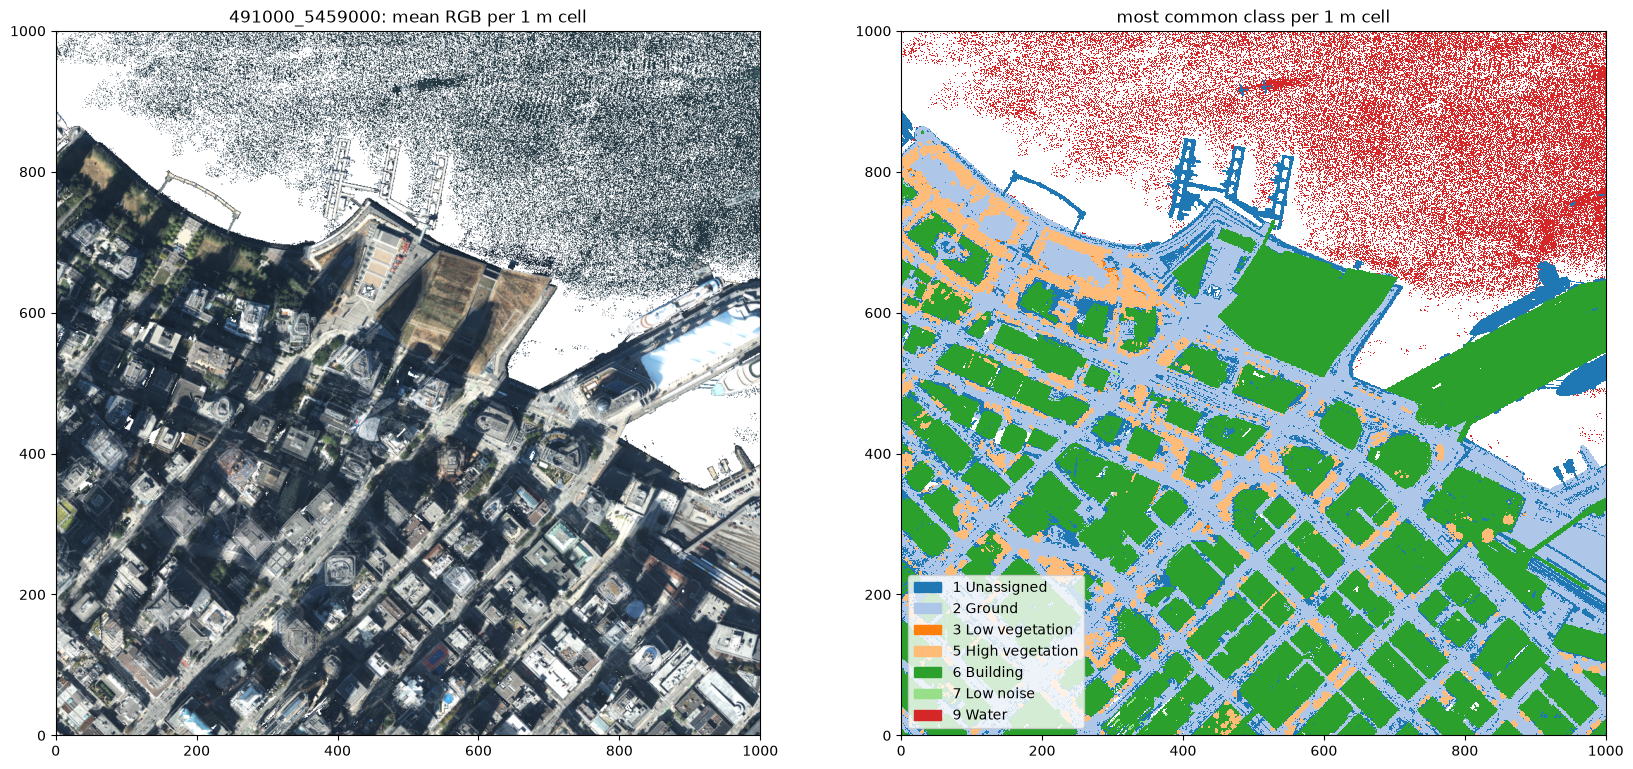

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
extent = (0, tile_size, 0, tile_size)
axs[0].imshow(np.nan_to_num(image, nan=1.0), extent=extent)
axs[0].set_title(f"{name}: mean RGB per 1 m cell")
present = list(per_class.index)
palette = plt.get_cmap("tab20").colors
cmap = ListedColormap([palette[i % 20] for i in range(len(present))])
norm = BoundaryNorm(np.arange(len(present) + 1) - 0.5, len(present))
class_index = np.full_like(majority, np.nan)
for i, c in enumerate(present):
    class_index[majority == c] = i
axs[1].imshow(class_index, cmap=cmap, norm=norm, interpolation="nearest", extent=extent)
axs[1].set_title("most common class per 1 m cell")
handles = [plt.Rectangle((0, 0), 1, 1, color=cmap(i)) for i in range(len(present))]
axs[1].legend(handles, [f"{c} {per_class.loc[c, 'name']}" for c in present], loc="lower left")
plt.show()

## Classes on a few more tiles

The full pass above takes a while per tile, so this only counts classes on a handful of different areas instead of all 181 tiles.

In [6]:
sample_tiles = {
    "Point Grey coast": "481000_5456000",
    "downtown": "491000_5459000",
    "residential east": "496000_5455000",
    "Fraser River": "490000_5449000",
}

def class_counts(name):
    counts = np.zeros(n_classes, np.int64)
    with open_tile(name) as r:
        for pts in r.chunk_iterator(chunk_size):
            counts += np.bincount(np.asarray(pts.classification), minlength=n_classes)
    return counts

sample_counts = pd.DataFrame({label: class_counts(t) for label, t in sample_tiles.items() if t in set(index_df["NAME"])})
sample_counts = sample_counts[sample_counts.sum(axis=1) > 0]
sample_counts.index = [f"{c} {asprs_classes.get(c, 'User defined')}" for c in sample_counts.index]
(100 * sample_counts / sample_counts.sum()).round(2)

,Point Grey coast,downtown,residential east,Fraser River
1 Unassigned,12.25,15.51,13.67,69.15
2 Ground,24.28,23.16,32.71,16.71
3 Low vegetation,3.42,0.25,3.59,1.71
5 High vegetation,44.25,11.95,29.43,2.69
6 Building,15.66,47.91,20.45,6.04
7 Low noise,0.12,0.57,0.14,0.05
9 Water,0.03,0.64,0.00,3.66


## Findings

- **Fields**: all 181 tiles are LAS 1.4, point format 7, exported from ArcGIS on 2023-02-25, with the same 21 fields and no extra dimensions. `user_data` is always 0 and `point_source_id` is the flight line.
- **Colours**: every point has 16-bit `red`/`green`/`blue`. They look sampled from an orthophoto rather than captured by the scanner: shadows are baked in and tall buildings carry the colour of whatever the photo shows at that x/y (relief displacement), so façades and edges are often wrong.
- **Classes**: only ASPRS 1, 2, 3, 5, 6, 7 and 9 occur in the sampled tiles. There is no medium vegetation (4), high noise (18), bridge deck (17) or road (11).
- **Ships are `1 Unassigned`**, not water: the cruise ship at Canada Place and the marina boats show up as class 1, while open water is sparse class 9 points (water absorbs the laser). On the Fraser River tile 69 % of points are unassigned, presumably barges, log booms and industry.
